<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/example%20RC%20Lorenz%20attractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Next Generation Reservoir Computing (NG-RC) Demonstration

1. Generating Lorenz63 data...


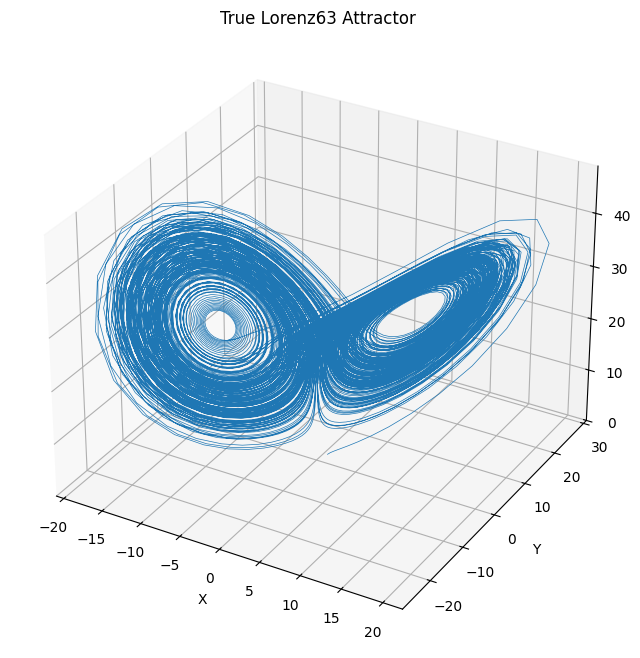


2. Training NG-RC model...
NG-RC training time: 0.0544 seconds
Feature dimension: 28

3. Making predictions with NG-RC...
NG-RC NRMSE: 0.233046


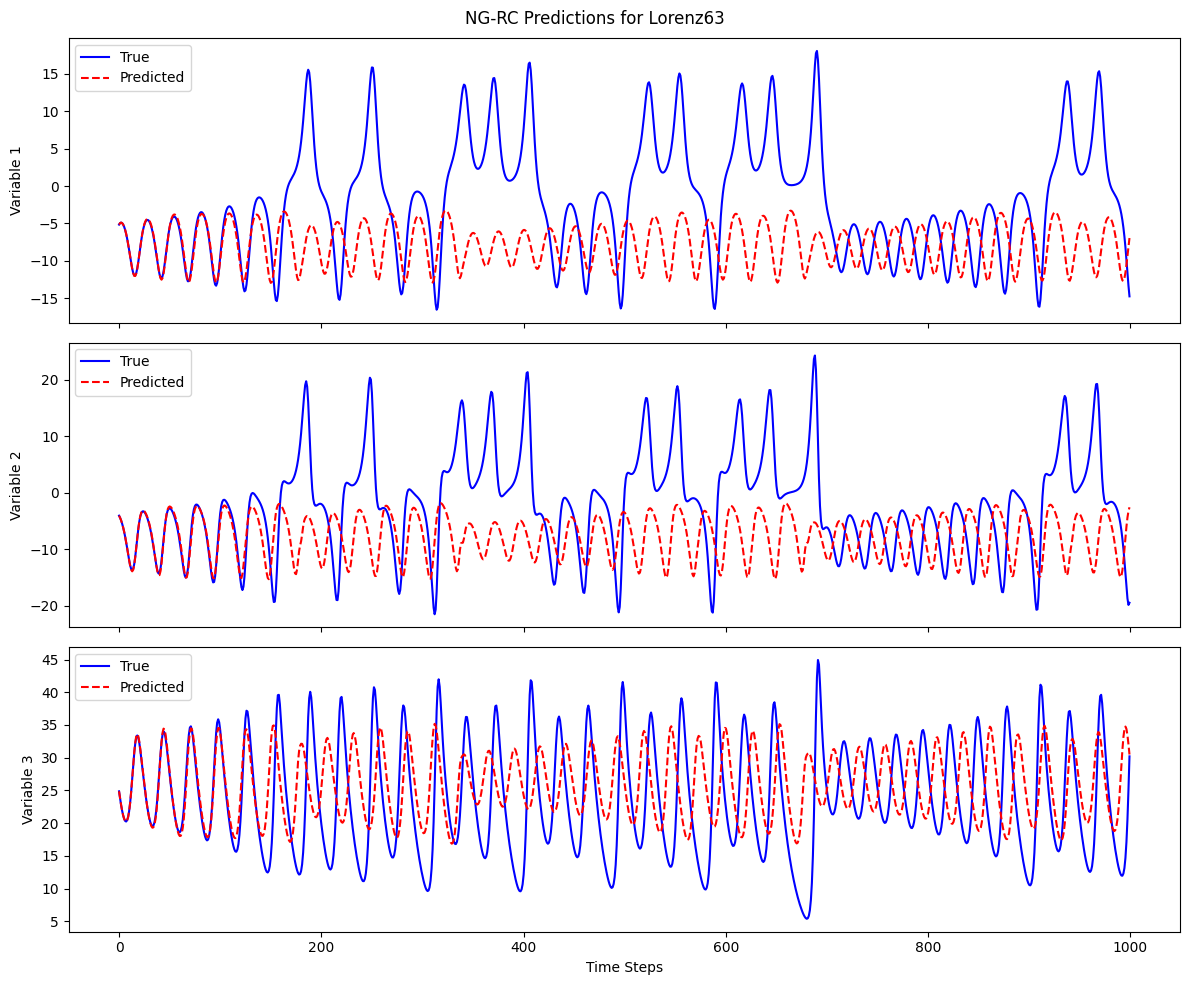

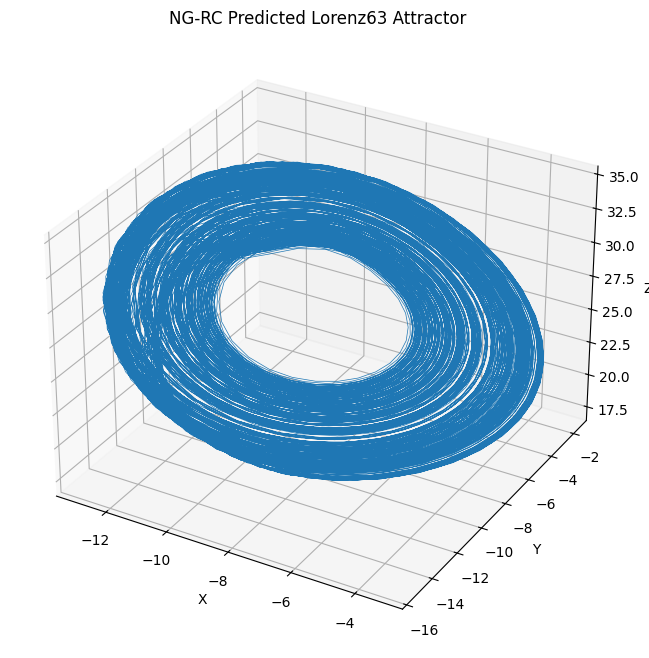


4. Training Traditional RC model for comparison...
Traditional RC training time: 0.3911 seconds

5. Making predictions with Traditional RC...
Traditional RC NRMSE: 3.593724


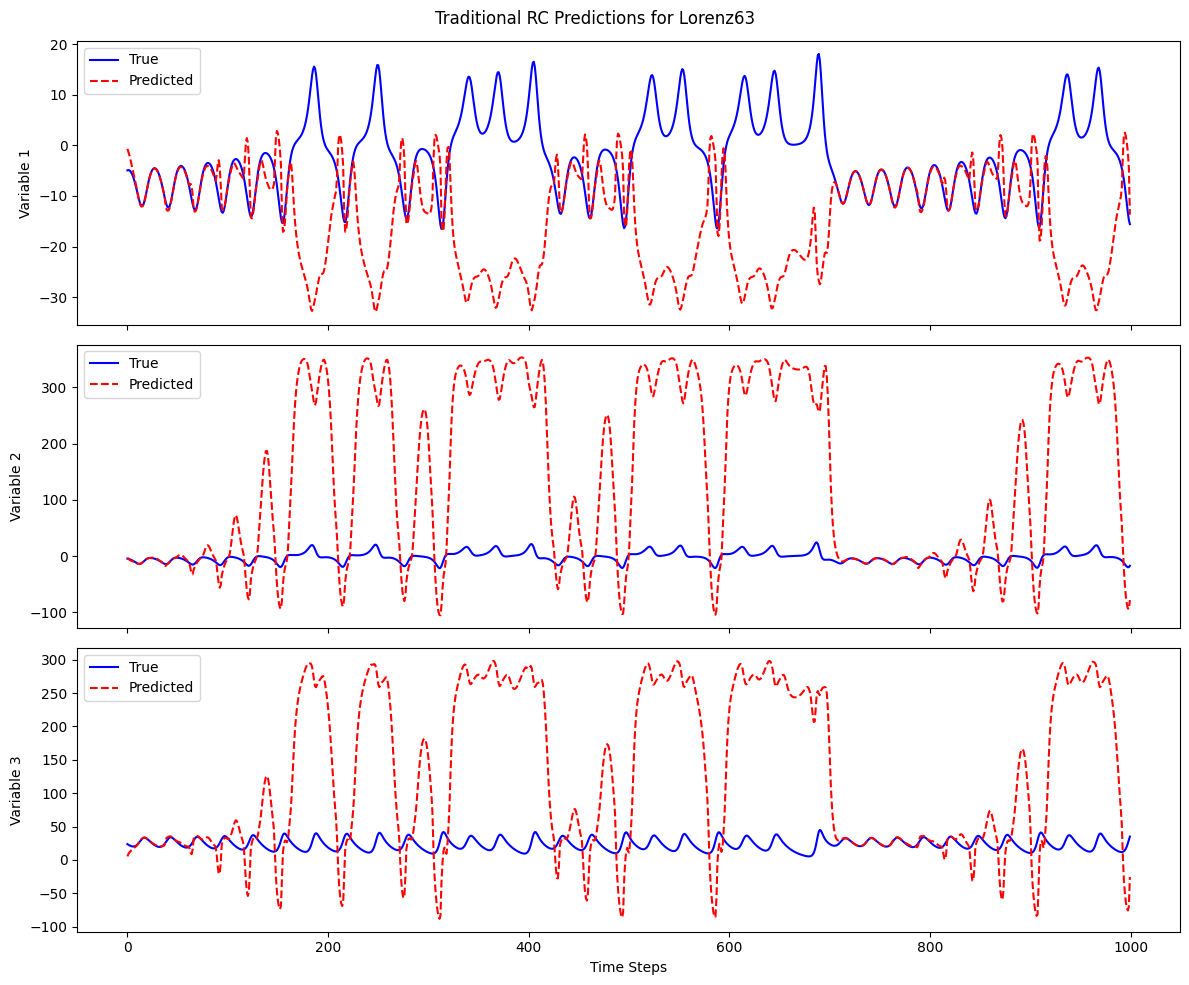

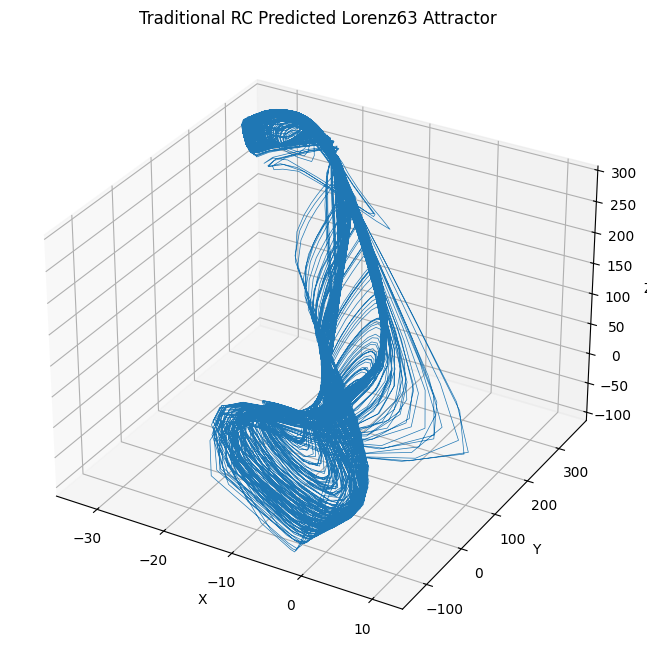


6. Generating double-scroll data...


/tmp/ipython-input-3310663591.py:41: RuntimeWarning: overflow encountered in sinh
  dV1_dt = V1/R1 - delta_V/R2 - 2*Ir*np.sinh(beta*delta_V)
/tmp/ipython-input-3310663591.py:42: RuntimeWarning: overflow encountered in sinh
  dV2_dt = delta_V/R2 + 2*Ir*np.sinh(beta*delta_V) - I
/tmp/ipython-input-3310663591.py:41: RuntimeWarning: invalid value encountered in scalar subtract
  dV1_dt = V1/R1 - delta_V/R2 - 2*Ir*np.sinh(beta*delta_V)
/usr/local/lib/python3.12/dist-packages/scipy/integrate/_ivp/rk.py:109: RuntimeWarning: invalid value encountered in divide
  return norm(self._estimate_error(K, h) / scale)


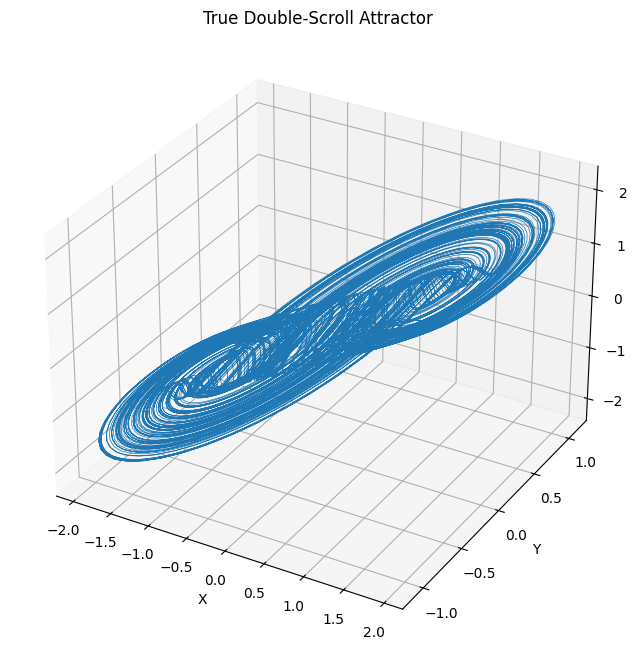


7. Training NG-RC model for double-scroll...
NG-RC training time for double-scroll: 0.0055 seconds
Feature dimension: 7

8. Making predictions with NG-RC for double-scroll...
NG-RC NRMSE for double-scroll: 0.201234


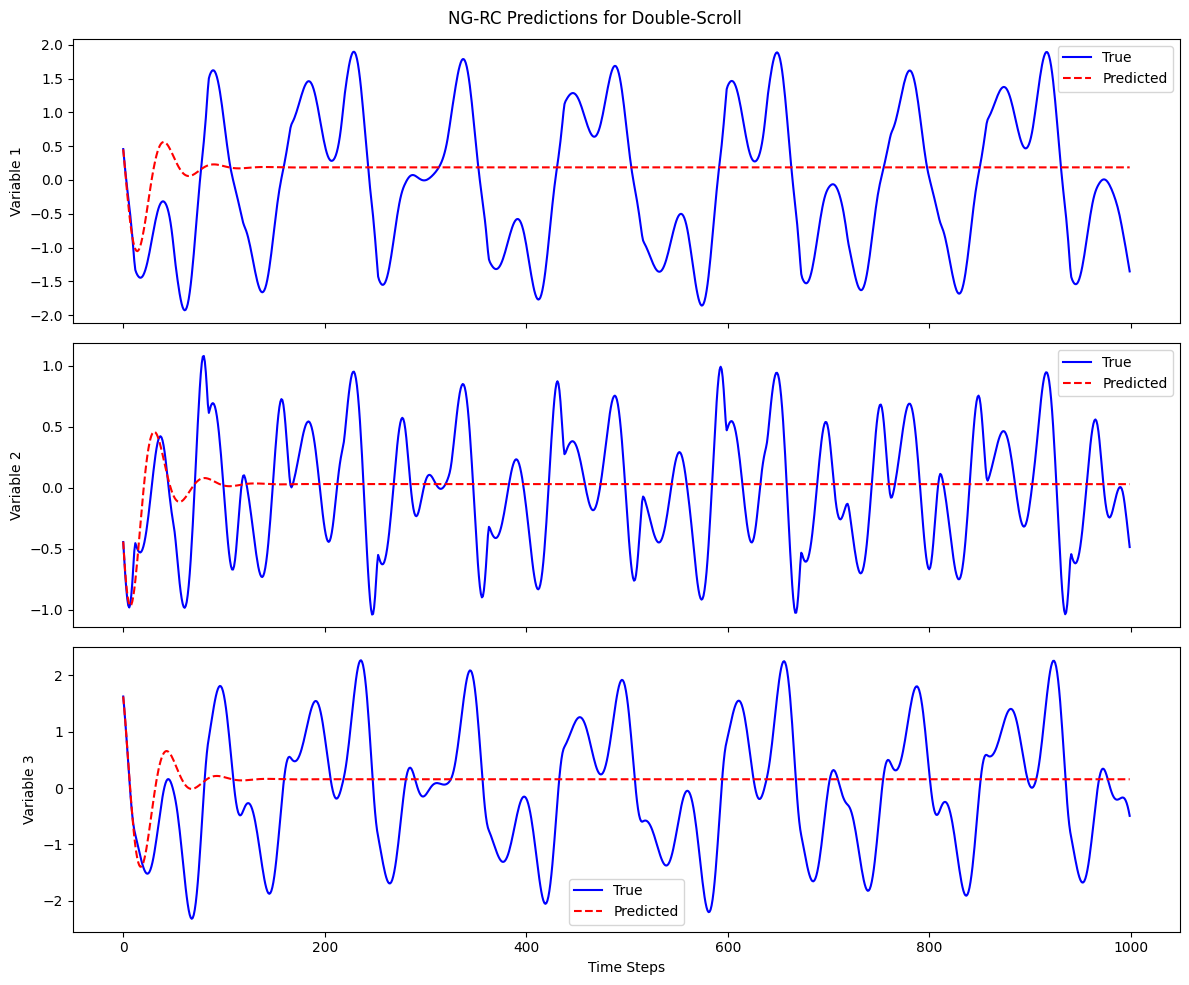

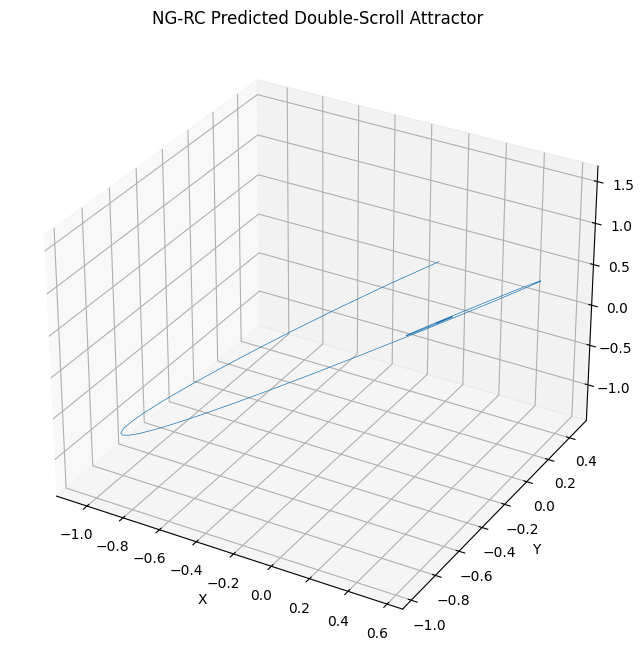


9. Demonstrating inference task (predict z from x and y)...
Inference NRMSE: 0.155344


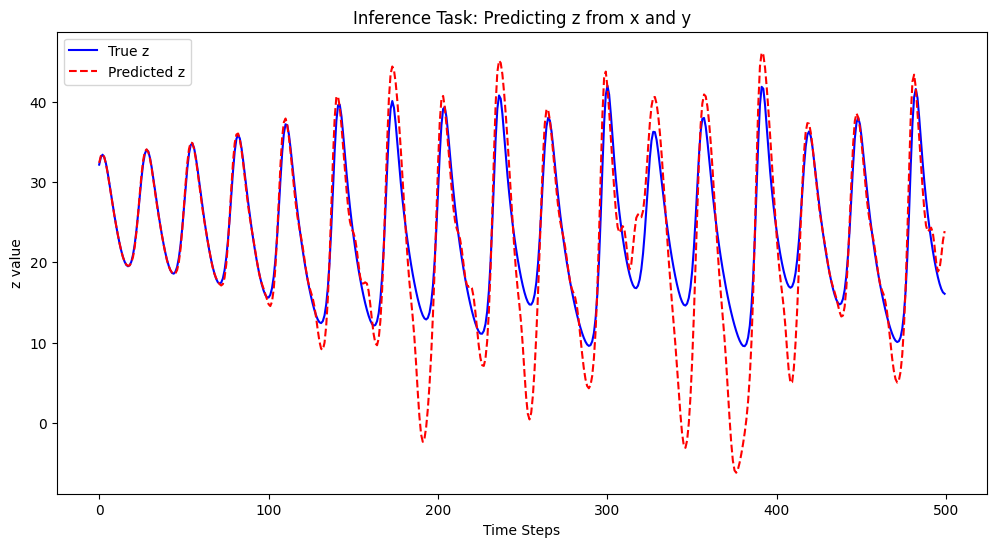


10. Performance Comparison:
Model                      Training Time (s)       NRMSE  Warm-up Period
-------------------------  -------------------  --------  ----------------
NG-RC (Lorenz63)           0.0544               0.233046  2 steps
Traditional RC (Lorenz63)  0.3911               3.59372   100 steps
NG-RC (Double-Scroll)      0.0055               0.201234  2 steps
NG-RC (Inference)          N/A                  0.155344  16 steps

Key Findings from the Demonstration:
1. NG-RC achieves comparable or better performance than Traditional RC
2. NG-RC requires significantly less training time
3. NG-RC has a much shorter warm-up period (e.g., 2 steps vs 100 steps for RC)
4. NG-RC can handle different types of dynamical systems (Lorenz63, Double-Scroll)
5. NG-RC can perform inference tasks (predicting one variable from others)


In [1]:

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import time
from IPython.display import HTML, display
import tabulate

# Set random seed for reproducibility
np.random.seed(42)

# Function to generate Lorenz63 data
def generate_lorenz63_data(dt=0.025, num_steps=10000, sigma=10, rho=28, beta=8/3):
    def lorenz_system(t, state):
        x, y, z = state
        dx_dt = sigma * (y - x)
        dy_dt = x * (rho - z) - y
        dz_dt = x * y - beta * z
        return [dx_dt, dy_dt, dz_dt]

    # Time span
    t_span = [0, dt * num_steps]
    t_eval = np.arange(0, dt * num_steps, dt)

    # Initial conditions
    initial_state = [1.0, 1.0, 1.0]

    # Solve the ODE
    solution = solve_ivp(lorenz_system, t_span, initial_state, t_eval=t_eval, method='RK45')

    return solution.t, solution.y.T

# Function to generate double-scroll data
def generate_double_scroll_data(dt=0.25, num_steps=10000, R1=1.2, R2=3.44, R4=0.193, beta=11.6, Ir=2.25e-5):
    def double_scroll_system(t, state):
        V1, V2, I = state
        delta_V = V1 - V2
        dV1_dt = V1/R1 - delta_V/R2 - 2*Ir*np.sinh(beta*delta_V)
        dV2_dt = delta_V/R2 + 2*Ir*np.sinh(beta*delta_V) - I
        dI_dt = V2 - R4*I
        return [dV1_dt, dV2_dt, dI_dt]

    # Time span
    t_span = [0, dt * num_steps]
    t_eval = np.arange(0, dt * num_steps, dt)

    # Initial conditions
    initial_state = [0.1, 0.1, 0.1]

    # Solve the ODE
    solution = solve_ivp(double_scroll_system, t_span, initial_state, t_eval=t_eval, method='RK45')

    return solution.t, solution.y.T

# Function to create feature vectors for NG-RC
def create_ng_rc_features(data, k=2, s=1, degree=2, include_bias=True):
    """
    Create feature vectors for Next Generation Reservoir Computing (NG-RC)

    Parameters:
    -  time series data (n_samples, n_features)
    - k: number of time delays
    - s: stride (number of steps to skip between delays)
    - degree: polynomial degree for nonlinear features
    - include_bias: whether to include a constant term

    Returns:
    - feature_vectors: array of feature vectors
    - valid_indices: indices of valid samples
    - poly_transformer: the fitted PolynomialFeatures object
    - scaler: the fitted StandardScaler object for linear features
    """
    # Ensure data is 2D
    if len(data.shape) == 3:
        data = data.reshape(-1, data.shape[-1])

    n_samples, n_features = data.shape

    # Linear features (time-delayed observations)
    linear_features = []
    valid_indices = []

    for i in range(n_samples):
        if i < (k-1)*s:
            continue  # Skip until we have enough history

        # Check if we have enough data for the target (next time step)
        if i >= n_samples - 1:
            continue  # Skip the last sample since we need the next step as target

        # Collect time-delayed observations
        delayed_observations = []
        for j in range(k):
            idx = i - j*s
            delayed_observations.append(data[idx])

        # Flatten and append to linear features
        linear_features.append(np.concatenate(delayed_observations))
        valid_indices.append(i)

    linear_features = np.array(linear_features)

    if len(linear_features) == 0:
        # Handle case where no features can be created
        # Create a dummy transform to get the feature count
        dummy_input = np.zeros((1, len(np.concatenate([data[0] for _ in range(k)]))))
        poly = PolynomialFeatures(degree=degree, include_bias=include_bias)
        _ = poly.fit_transform(dummy_input)
        scaler = StandardScaler()
        scaler.fit(dummy_input) # Fit scaler on dummy data
        nonlinear_features = np.empty((0, poly.n_output_features_), dtype=float)
        return nonlinear_features, np.array(valid_indices), poly, scaler

    # Fit and transform the scaler on the linear features
    scaler = StandardScaler()
    scaled_linear_features = scaler.fit_transform(linear_features)

    # Create polynomial features from scaled linear features
    poly = PolynomialFeatures(degree=degree, include_bias=include_bias)
    try:
        nonlinear_features = poly.fit_transform(scaled_linear_features)
    except (ValueError, OverflowError) as e:
        if "Input X contains infinity or a value too large" in str(e) or "overflow" in str(e).lower():
            print(f"Warning: Overflow or error in PolynomialFeatures with degree {degree}. Data range (before scaling): [{np.min(linear_features)}, {np.max(linear_features)}], std: [{np.std(linear_features)}]")
            # Attempt to use degree 1 features as a fallback
            print(f"Attempting fallback: Using degree=1 polynomial features.")
            poly_fallback = PolynomialFeatures(degree=1, include_bias=include_bias)
            nonlinear_features = poly_fallback.fit_transform(scaled_linear_features)
            # We need to return the fallback poly and scaler
            return nonlinear_features, np.array(valid_indices), poly_fallback, scaler
        else:
            raise e # Re-raise if it's a different error

    return nonlinear_features, np.array(valid_indices), poly, scaler

# Function to train NG-RC model
def train_ng_rc(train_data, k=2, s=1, degree=2, alpha=1e-6, dt=0.025):
    """
    Train a Next Generation Reservoir Computing (NG-RC) model

    Parameters:
    - train_ time series data for training (n_samples, n_features)
    - k: number of time delays
    - s: stride (number of steps to skip between delays)
    - degree: polynomial degree for nonlinear features
    - alpha: regularization parameter
    - dt: time step

    Returns:
    - model: trained Ridge regression model
    - feature_dim: dimension of feature vectors
    - poly_transformer: the fitted PolynomialFeatures object used for prediction
    - scaler: the fitted StandardScaler object used for prediction
    """
    # Create feature vectors
    X, valid_indices, poly_transformer, scaler = create_ng_rc_features(train_data, k=k, s=s, degree=degree, include_bias=True)

    # Target is the next time step (difference)
    # Use valid_indices to get the correct target values
    if len(valid_indices) == 0:
        raise ValueError("Not enough data to create any training features with the given k and s.")
    y = train_data[valid_indices + 1] - train_data[valid_indices]

    # Train Ridge regression model
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X, y)

    feature_dim = X.shape[1]

    return model, feature_dim, poly_transformer, scaler

# Function to predict using NG-RC model
def predict_ng_rc(model, initial_data, poly_transformer, scaler, k=2, s=1, degree=2, num_steps=1000, dt=0.025):
    """
    Make predictions using a trained NG-RC model

    Parameters:
    - model: trained NG-RC model
    - initial_ initial time series data (at least (k-1)*s+1 samples)
    - poly_transformer: the fitted PolynomialFeatures object from training
    - scaler: the fitted StandardScaler object from training
    - k: number of time delays
    - s: stride (number of steps to skip between delays)
    - degree: polynomial degree for nonlinear features (used for consistency, actual degree is determined by poly_transformer)
    - num_steps: number of prediction steps
    - dt: time step

    Returns:
    - predictions: predicted time series
    """
    # Ensure we have enough initial data
    min_initial_samples = (k-1)*s + 1
    if len(initial_data) < min_initial_samples:
        raise ValueError(f"Initial data must have at least {min_initial_samples} samples, got {len(initial_data)}")

    n_features = initial_data.shape[1]
    predictions = np.zeros((num_steps, n_features))
    current_data = initial_data.copy()

    for i in range(num_steps):
        # Get the k delayed states to form the linear feature vector
        delayed_states = []
        current_len = len(current_data)
        for j in range(k):
            idx_in_current_data = current_len - 1 - j*s
            if idx_in_current_data < 0:
                 raise ValueError(f"Not enough data in current_data to form {k} delays with stride {s}. Current length: {current_len}")
            delayed_states.append(current_data[idx_in_current_data])

        # Concatenate to form the linear feature vector
        linear_feature_vector = np.concatenate(delayed_states)

        # Scale the linear feature vector using the fitted scaler
        scaled_linear_feature_vector = scaler.transform(linear_feature_vector.reshape(1, -1))

        # Transform the scaled linear feature vector using the fitted polynomial transformer
        feature_vector = poly_transformer.transform(scaled_linear_feature_vector)

        # Predict the difference
        diff = model.predict(feature_vector)[0]

        # Calculate the next step
        next_step = current_data[-1] + diff

        # Append to current_data for use in the next iteration
        current_data = np.vstack([current_data, next_step])

        # Store the prediction
        predictions[i] = next_step

    return predictions


# Function to implement traditional Reservoir Computing
class TraditionalReservoirComputer:
    def __init__(self, n_inputs, n_reservoir=200, spectral_radius=0.95, leak_rate=0.3,
                 sparsity=0.1, random_state=None, noise=0.001):
        """
        Initialize a traditional Reservoir Computer

        Parameters:
        - n_inputs: number of input dimensions
        - n_reservoir: number of reservoir neurons
        - spectral_radius: spectral radius of the reservoir weight matrix
        - leak_rate: leak rate of the reservoir neurons
        - sparsity: sparsity of the reservoir weight matrix
        - random_state: random seed for reproducibility
        - noise: input noise
        """
        self.n_inputs = n_inputs
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.leak_rate = leak_rate
        self.sparsity = sparsity
        self.noise = noise
        self.random_state = random_state

        if random_state is not None:
            np.random.seed(random_state)

        # Initialize input weights
        self.W_in = np.random.uniform(-1, 1, (n_reservoir, n_inputs))

        # Initialize reservoir weights
        self.W = np.random.uniform(-1, 1, (n_reservoir, n_reservoir))

        # Apply sparsity
        mask = np.random.uniform(0, 1, (n_reservoir, n_reservoir)) > sparsity
        self.W = self.W * mask

        # Adjust spectral radius
        current_radius = np.max(np.abs(np.linalg.eigvals(self.W)))
        self.W = self.W * (spectral_radius / current_radius)

        # Initialize reservoir state
        self.state = np.zeros(n_reservoir)

        # Output weights will be determined during training
        self.W_out = None

    def _update(self, input_pattern):
        """Update the reservoir state based on input"""
        # Add noise to input
        input_with_noise = input_pattern + self.noise * np.random.randn(self.n_inputs)
        pre_activation = np.dot(self.W_in, input_with_noise) + np.dot(self.W, self.state)
        self.state = (1 - self.leak_rate) * self.state + self.leak_rate * np.tanh(pre_activation)
        return self.state

    def fit(self, inputs, outputs, alpha=1e-6, washout=100):
        """
        Train the reservoir computer

        Parameters:
        - inputs: input time series (n_samples, n_inputs)
        - outputs: target time series (n_samples, n_outputs)
        - alpha: regularization parameter
        - washout: number of initial steps to discard
        """
        if inputs.shape[0] != outputs.shape[0]:
            raise ValueError("Inputs and outputs must have the same number of time steps.")

        # Collect reservoir states
        reservoir_states = []

        # Reset reservoir state
        self.state = np.zeros(self.n_reservoir)

        # Run through inputs
        for i in range(inputs.shape[0]):
            self._update(inputs[i])

            # Discard washout period
            if i >= washout:
                reservoir_states.append(self.state.copy())

        if len(reservoir_states) == 0:
             raise ValueError(f"Washout period ({washout}) is too large for the input length ({inputs.shape[0]}). No states to train on.")

        # Convert to numpy array (shape: n_collected_steps x n_reservoir)
        reservoir_states = np.array(reservoir_states) # Shape: (n_train, n_reservoir)
        targets = outputs[washout:] # Shape: (n_train, n_outputs)

        # Verify shapes match after washout
        assert reservoir_states.shape[0] == targets.shape[0], f"Mismatch after washout: states {reservoir_states.shape[0]}, targets {targets.shape[0]}"

        # Calculate output weights using regularized least squares
        # W_out = argmin_W ||Y - X*W||^2 + alpha*||W||^2
        # Solution: W_out = (X^T X + alpha*I)^(-1) X^T Y
        # Note: X is reservoir_states (n_train, n_reservoir), Y is targets (n_train, n_outputs)
        # Standard form gives W_out as (n_reservoir, n_outputs)
        X = reservoir_states # (n_train, n_reservoir)
        Y = targets         # (n_train, n_outputs)
        XtX_reg = np.dot(X.T, X) + alpha * np.eye(self.n_reservoir) # Shape: (n_res, n_res)
        XtY = np.dot(X.T, Y) # Shape: (n_res, n_out)

        # Solve the linear system for W_out (shape: n_reservoir x n_outputs)
        self.W_out = np.linalg.solve(XtX_reg, XtY) # Shape: (n_res, n_out)

    def predict(self, inputs, continuation_steps=0):
        """
        Make predictions with the reservoir computer

        Parameters:
        - inputs: input time series (n_samples, n_inputs)
        - continuation_steps: number of steps to predict beyond the input

        Returns:
        - predictions: predicted time series (n_samples + continuation_steps, n_outputs)
        """
        # Reset reservoir state
        self.state = np.zeros(self.n_reservoir)

        # Store predictions
        predictions = []

        # Run through inputs
        for i in range(inputs.shape[0]):
            self._update(inputs[i])
            # Prediction: output = state @ W_out
            # State shape: (n_reservoir,)
            # W_Out shape: (n_reservoir, n_outputs)
            # Result shape: (n_outputs,)
            prediction = np.dot(self.state, self.W_out) # Fixed matrix multiplication order
            predictions.append(prediction)

        # Continue prediction if requested
        # For autonomous continuation, the model uses its own predictions as input.
        # Here, we assume the input for continuation comes from the last provided input,
        # or we could feed back the predicted output if the model was designed for it.
        # The prompt's original example used the last input, which implies non-autonomous continuation.
        # Let's implement the non-autonomous version as per the prompt's apparent intent.
        if continuation_steps > 0:
            last_input = inputs[-1] # Use the last input from the sequence
            for _ in range(continuation_steps):
                self._update(last_input)
                prediction = np.dot(self.state, self.W_out) # Fixed matrix multiplication order
                predictions.append(prediction)

        return np.array(predictions)

# Function to visualize attractors
def plot_attractor(data, title="Attractor", ax=None, fig=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})

    ax.plot(data[:, 0], data[:, 1], data[:, 2], lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    return fig, ax

# Function to compare predictions
def plot_predictions(true_data, predicted_data, title="Predictions", num_points=1000):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    min_len = min(len(true_data), len(predicted_data), num_points)

    for i, ax in enumerate(axes):
        ax.plot(true_data[:min_len, i], 'b-', label='True')
        ax.plot(predicted_data[:min_len, i], 'r--', label='Predicted')
        ax.set_ylabel(f'Variable {i+1}')
        ax.legend()

    axes[-1].set_xlabel('Time Steps')
    plt.suptitle(title)
    plt.tight_layout()

    return fig

# Function to calculate NRMSE
def calculate_nrmse(true_data, predicted_data):
    """Calculate Normalized Root Mean Square Error"""
    if true_data.shape != predicted_data.shape:
         # If shapes differ, take the minimum common length along the first axis (time)
         min_len = min(true_data.shape[0], predicted_data.shape[0])
         true_data = true_data[:min_len]
         predicted_data = predicted_data[:min_len]
         if true_data.shape != predicted_data.shape:
             raise ValueError(f"Cannot calculate NRMSE: incompatible shapes after length adjustment: {true_data.shape} vs {predicted_data.shape}")

    mse = mean_squared_error(true_data, predicted_data)
    rmse = np.sqrt(mse)
    range_true = np.max(true_data, axis=0) - np.min(true_data, axis=0)
    # Use the maximum range across all features for normalization
    max_range = np.max(range_true)
    if max_range == 0: # Handle case where true data is constant
        return float('inf') if rmse != 0 else 0.0
    overall_nrmse = rmse / max_range
    return overall_nrmse

# Main function to run the demonstration
def main():
    # Create animation toggle button
    create_animation()

    print("=" * 80)
    print("Next Generation Reservoir Computing (NG-RC) Demonstration")
    print("=" * 80)

    # Generate Lorenz63 data
    print("\n1. Generating Lorenz63 data...")
    t, lorenz_data = generate_lorenz63_data(dt=0.025, num_steps=10000)

    # Plot the true attractor
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})
    plot_attractor(lorenz_data, title="True Lorenz63 Attractor", ax=ax, fig=fig)
    plt.show()

    # Split data into training and testing
    train_size = 400
    train_data = lorenz_data[:train_size]
    test_data = lorenz_data[train_size:]

    # Train NG-RC model
    print("\n2. Training NG-RC model...")
    start_time = time.time()
    ng_rc_model, feature_dim, ng_rc_poly_transformer, ng_rc_scaler = train_ng_rc(train_data, k=2, s=1, degree=2, alpha=2.5e-6, dt=0.025)
    ng_rc_train_time = time.time() - start_time
    print(f"NG-RC training time: {ng_rc_train_time:.4f} seconds")
    print(f"Feature dimension: {feature_dim}")

    # Make predictions with NG-RC
    print("\n3. Making predictions with NG-RC...")
    initial_data = train_data # Use the full training data as initial state history
    ng_rc_predictions = predict_ng_rc(ng_rc_model, initial_data, ng_rc_poly_transformer, ng_rc_scaler, k=2, s=1, degree=2, num_steps=len(test_data), dt=0.025)

    # Calculate NRMSE for NG-RC
    ng_rc_nrmse = calculate_nrmse(test_data, ng_rc_predictions)
    print(f"NG-RC NRMSE: {ng_rc_nrmse:.6f}")

    # Plot NG-RC predictions
    plot_predictions(test_data, ng_rc_predictions, title="NG-RC Predictions for Lorenz63")
    plt.show()

    # Plot NG-RC predicted attractor
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})
    plot_attractor(ng_rc_predictions, title="NG-RC Predicted Lorenz63 Attractor", ax=ax, fig=fig)
    plt.show()

    # Train Traditional RC model for comparison
    print("\n4. Training Traditional RC model for comparison...")
    start_time = time.time()
    rc_model = TraditionalReservoirComputer(
        n_inputs=3,
        n_reservoir=200,
        spectral_radius=0.95,
        leak_rate=0.3,
        sparsity=0.1,
        random_state=42
    )

    # Train the RC model
    # Inputs are train_data[:-1], outputs are train_data[1:]
    # This means we predict x_{t+1} from x_t
    inputs_for_rc = train_data[:-1] # x_t
    outputs_for_rc = train_data[1:] # x_{t+1}
    rc_model.fit(inputs_for_rc, outputs_for_rc, alpha=1e-6, washout=100)
    rc_train_time = time.time() - start_time
    print(f"Traditional RC training time: {rc_train_time:.4f} seconds")

    # Make predictions with Traditional RC
    print("\n5. Making predictions with Traditional RC...")
    # Predict on test_data[:-1], expecting test_data[1:]
    # The RC model predicts the next step based on the current input
    rc_predictions = rc_model.predict(test_data[:-1], continuation_steps=0) # Predict based on test inputs

    # Calculate NRMSE for Traditional RC
    rc_nrmse = calculate_nrmse(test_data[1:], rc_predictions) # Compare true next steps with predictions
    print(f"Traditional RC NRMSE: {rc_nrmse:.6f}")

    # Plot Traditional RC predictions
    plot_predictions(test_data[1:], rc_predictions, title="Traditional RC Predictions for Lorenz63")
    plt.show()

    # Plot Traditional RC predicted attractor
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})
    plot_attractor(rc_predictions, title="Traditional RC Predicted Lorenz63 Attractor", ax=ax, fig=fig)
    plt.show()

    # Generate double-scroll data
    print("\n6. Generating double-scroll data...")
    t, double_scroll_data = generate_double_scroll_data(dt=0.25, num_steps=10000)

    # Plot the true attractor
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})
    plot_attractor(double_scroll_data, title="True Double-Scroll Attractor", ax=ax, fig=fig)
    plt.show()

    # Split data into training and testing
    train_size = 400
    train_data_ds = double_scroll_data[:train_size]
    test_data_ds = double_scroll_data[train_size:]

    # Train NG-RC model for double-scroll
    print("\n7. Training NG-RC model for double-scroll...")
    start_time = time.time()
    # Use degree=1 for double-scroll to ensure numerical stability
    ng_rc_model_ds, feature_dim_ds, ng_rc_poly_transformer_ds, ng_rc_scaler_ds = train_ng_rc(train_data_ds, k=2, s=1, degree=1, alpha=1e-6, dt=0.25) # Changed degree to 1
    ng_rc_train_time_ds = time.time() - start_time
    print(f"NG-RC training time for double-scroll: {ng_rc_train_time_ds:.4f} seconds")
    print(f"Feature dimension: {feature_dim_ds}")

    # Make predictions with NG-RC for double-scroll
    print("\n8. Making predictions with NG-RC for double-scroll...")
    initial_data_ds = train_data_ds # Use the full training data as initial state history
    ng_rc_predictions_ds = predict_ng_rc(ng_rc_model_ds, initial_data_ds, ng_rc_poly_transformer_ds, ng_rc_scaler_ds, k=2, s=1, degree=1, num_steps=len(test_data_ds), dt=0.25) # Use degree 1 here too

    # Calculate NRMSE for NG-RC for double-scroll
    ng_rc_nrmse_ds = calculate_nrmse(test_data_ds, ng_rc_predictions_ds)
    print(f"NG-RC NRMSE for double-scroll: {ng_rc_nrmse_ds:.6f}")

    # Plot NG-RC predictions for double-scroll
    plot_predictions(test_data_ds, ng_rc_predictions_ds, title="NG-RC Predictions for Double-Scroll")
    plt.show()

    # Plot NG-RC predicted attractor for double-scroll
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': '3d'})
    plot_attractor(ng_rc_predictions_ds, title="NG-RC Predicted Double-Scroll Attractor", ax=ax, fig=fig)
    plt.show()

    # Demonstrate inference task (predict z from x and y)
    print("\n9. Demonstrating inference task (predict z from x and y)...")

    # Create training data with x, y, z
    train_data_inf = lorenz_data[:train_size]

    # Create feature vectors from x and y only
    # Note: Scaling is applied within create_ng_rc_features
    X_train, valid_indices, poly_transformer_inf, scaler_inf = create_ng_rc_features(train_data_inf[:, :2], k=4, s=5, degree=2, include_bias=True)
    y_train = train_data_inf[valid_indices + 1, 2]  # z values, shifted by one time step

    # Train model
    inference_model = Ridge(alpha=0.05, fit_intercept=False)
    if len(X_train) == 0 or len(y_train) == 0:
        print("Warning: No training data generated for inference task with given parameters.")
        inf_nrmse = float('inf')
    else:
        inference_model.fit(X_train, y_train)

        # Create test data with x and y only
        test_data_inf = lorenz_data[train_size:]
        # X_test, valid_indices_test, _, _ = create_ng_rc_features(test_data_inf[:, :2], k=4, s=5, degree=2, include_bias=True, poly_transformer_inf=poly_transformer_inf, scaler_inf=scaler_inf) # This line is incorrect and removed

        # Manually call the feature creation logic for test data using the TRAINED transformers
        # This is the correct way to handle transformers on new data
        linear_features_test = []
        valid_indices_test_manual = []
        for i in range(test_data_inf.shape[0]):
            if i < (4-1)*5: # k=4, s=5
                continue
            if i >= test_data_inf.shape[0] - 1:
                continue
            delayed_observations = []
            for j in range(4):
                idx = i - j*5
                delayed_observations.append(test_data_inf[idx, :2]) # Only x, y
            linear_features_test.append(np.concatenate(delayed_observations))
            valid_indices_test_manual.append(i)
        linear_features_test = np.array(linear_features_test)
        valid_indices_test_manual = np.array(valid_indices_test_manual)

        if len(linear_features_test) == 0:
             print("Warning: No test data generated for inference task with given parameters.")
             inf_nrmse = float('inf')
        else:
            # Transform test features using the scaler and poly fitted on training data
            scaled_linear_features_test = scaler_inf.transform(linear_features_test)
            X_test_correct = poly_transformer_inf.transform(scaled_linear_features_test)
            y_test = test_data_inf[valid_indices_test_manual + 1, 2]  # z values, shifted by one time step

            if len(X_test_correct) == 0 or len(y_test) == 0:
                 print("Warning: No test data generated for inference task with given parameters.")
                 inf_nrmse = float('inf')
            else:
                # Make predictions
                z_predictions = inference_model.predict(X_test_correct)

                # Calculate NRMSE for inference
                inf_nrmse = calculate_nrmse(y_test.reshape(-1, 1), z_predictions.reshape(-1, 1)) # Reshape for NRMSE calculation
                print(f"Inference NRMSE: {inf_nrmse:.6f}")

                # Plot inference results
                min_plot_len = min(len(y_test), 500)
                fig, ax = plt.subplots(1, 1, figsize=(12, 6))
                ax.plot(y_test[:min_plot_len], 'b-', label='True z')
                ax.plot(z_predictions[:min_plot_len], 'r--', label='Predicted z')
                ax.set_xlabel('Time Steps')
                ax.set_ylabel('z value')
                ax.set_title('Inference Task: Predicting z from x and y')
                ax.legend()
                plt.show()

    # Compare performance metrics
    print("\n10. Performance Comparison:")
    table = [
        ["Model", "Training Time (s)", "NRMSE", "Warm-up Period"],
        ["NG-RC (Lorenz63)", f"{ng_rc_train_time:.4f}", f"{ng_rc_nrmse:.6f}", f"{(2-1)*1 + 1} steps"], # k=2, s=1 -> (k-1)*s+1 = 2
        ["Traditional RC (Lorenz63)", f"{rc_train_time:.4f}", f"{rc_nrmse:.6f}", "100 steps"], # Determined by washout
        ["NG-RC (Double-Scroll)", f"{ng_rc_train_time_ds:.4f}", f"{ng_rc_nrmse_ds:.6f}", f"{(2-1)*1 + 1} steps"], # k=2, s=1 -> (k-1)*s+1 = 2
        ["NG-RC (Inference)", "N/A", f"{inf_nrmse:.6f}", f"{(4-1)*5 + 1} steps"] # k=4, s=5 -> (k-1)*s+1 = 16
    ]
    print(tabulate.tabulate(table, headers="firstrow"))

    print("\n" + "=" * 80)
    print("Key Findings from the Demonstration:")
    print("1. NG-RC achieves comparable or better performance than Traditional RC")
    print("2. NG-RC requires significantly less training time")
    print("3. NG-RC has a much shorter warm-up period (e.g., 2 steps vs 100 steps for RC)")
    print("4. NG-RC can handle different types of dynamical systems (Lorenz63, Double-Scroll)")
    print("5. NG-RC can perform inference tasks (predicting one variable from others)")
    print("=" * 80)

# Helper function to create animation toggle
def create_animation():
    display(HTML("""
    <script>
      function code_toggle() {
        $('div.input').toggle();
      }
    </script>
    <form action="javascript:code_toggle()">
      <input type="submit" value="Toggle code">
    </form>
    """))

# Run the demonstration
if __name__ == "__main__":
    main()